# Multiple Sclerosis Lesion Segmentation: Pipeline & External Validation
**Project:** Master's Thesis (TFM)  
**Author:** Manuel Navarro Sicre  
**Framework:** [nnU-Net v2](https://github.com/MIC-DKFZ/nnUNet)

---

## 1. Overview
This notebook implements the full inference and evaluation pipeline for Multiple Sclerosis (MS) lesion segmentation. The project focuses on assessing the **generalization capability** of a deep learning model when deployed on an external, multi-center dataset.



### 1.1 The Model
* **Architecture:** nnU-Net 3d_fullres.
* **Training Data:** Multimodal MRI (FLAIR + T1-weighted).
* **Internal Performance:** 0.6848 Foreground Mean Dice Score.

---

## 2. The External Validation Challenge (MSSEG-2)
To test the model in a "real-world" scenario, we use the **MSSEG-2 (MICCAI 2021)** challenge dataset. This introduces two major technical hurdles:

1. **Domain Shift:** Data comes from different scanners and hospitals than those used during training.
2. **Missing Modalities:** MSSEG-2 only provides FLAIR sequences. Since our model was trained as a multimodal system (FLAIR + T1), it expects 4 input channels (2 timepoints × 2 modalities).

### 2.1 The "Bypass" Strategy: Channel Cloning
To run the model without the native T1 sequence, we implement a **Channel Cloning** preprocessing step:
* **Channel 0 & 1 (Time 01):** FLAIR is duplicated to fill the T1 slot.
* **Channel 2 & 3 (Time 02):** FLAIR is duplicated to fill the T1 slot.

> **Note:** This strategy allows the code to run, but it creates a "distribution shift" that significantly impacts the final Dice metrics, providing a valuable case study on model robustness and dependency on multimodal data.

In [ ]:
# Requirements
!pip install nnunetv2 nibabel matplotlib pandas

import os
import json
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shutil

In [6]:
# Environment variables
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/nnUNet_results'

In [ ]:
# Kaggle token (Username & key)
data = {"username":"xxxxx","key":"xxxxx"}  # Change "xxxxx" for your own values

with open('kaggle.json', 'w') as f:
    json.dump(data, f)

print("kaggle.json file created successfully.")

## Upload training dataset

In [ ]:
# Move the token to the hidden settings folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download de dataset from Kaggle, faster than locally
!pip install kaggle --upgrade > /dev/null
!kaggle datasets download -d username/nnunet-ms-raw # Change "username" for yours

# Create destination folder and unzip
!mkdir -p /content/nnUNet_raw/nnunet-ms-raw
!unzip -q nnunet-ms-raw.zip -d /content/nnUNet_raw/nnunet-ms-raw

!rm nnunet-ms-raw.zip

print("Dataset ready")
!ls -l /content/nnUNet_raw/nnunet-ms-raw

### Generate dataset.json

In [ ]:
# Configuration (Parameters)
DATASET_ID = 'Dataset001_MSLesions'
BASE_PATH = f'/content/nnUNet_raw/nnUNet-ms-raw/{DATASET_ID}'
IMAGES_TR_PATH = os.path.join(BASE_PATH, 'imagesTr')

# Default metadata configuration
DATASET_INFO = {
    "channel_names": {
        "0": "FLAIR_baseline",
        "1": "T1_baseline",
        "2": "FLAIR_followup",
        "3": "T1_followup"
    },
    "labels": {
        "background": 0,
        "lesion": 1,
        "new_lesion": 2
    },
    "numTraining": 349
}

# Directory verification & extension detection
if not os.path.exists(IMAGES_TR_PATH):
    print(f"ERROR: Training folder not found at {IMAGES_TR_PATH}")
else:
    training_files = sorted(os.listdir(IMAGES_TR_PATH))
    num_files = len(training_files)

    if num_files == 0:
        print(f"WARNING: No files found in {IMAGES_TR_PATH}")
    else:
        # Detect actual file extension (.nii or .nii.gz)
        sample_file = training_files[0]
        detected_extension = ".nii.gz" if sample_file.endswith(".nii.gz") else ".nii"

        print(f"Found {num_files} training images.")
        print(f"Extension detected: {detected_extension}")

        # Generate dataset.json
        DATASET_INFO["file_ending"] = detected_extension

        json_output_path = os.path.join(BASE_PATH, 'dataset.json')
        with open(json_output_path, 'w') as f:
            json.dump(DATASET_INFO, f, indent=4)

        print(f"Successfully updated 'dataset.json' at: {json_output_path}")

print("\n--- Current Dataset Structure ---")
!ls -F {BASE_PATH}

### Run planning and preprocessing

In [ ]:
# -d: Dataset ID (1)
# -c: Configuration (3d_fullres)
# --verify_dataset_integrity: Checks for format errors before starting
!nnUNetv2_plan_and_preprocess -d 1 -c 3d_fullres --verify_dataset_integrity

Fingerprint extraction...
Dataset001_MSLesions
Using <class 'nnunetv2.imageio.nibabel_reader_writer.NibabelIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.nibabel_reader_writer.NibabelIO'> as reader/writer
Extracting dataset fingerprint: 100% 349/349 [03:00<00:00,  1.93it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [156. 154. 200.], 3d_lowres: [156, 154, 200]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size':

### Run training

In [ ]:
# 1: Dataset ID
# 3d_fullres: Configuration
# 0: Fold number (0-4)
# To train a full model, you would normally run 5 folds.
# !nnUNetv2_train 1 3d_fullres 0
print("Training command: nnUNetv2_train 1 3d_fullres 0")
print("Note: This step was previously completed. Pre-trained weights are located in the nnUNet_results folder.")

Se han truncado las últimas 5000 líneas del flujo de salida.
2026-05-10 22:26:45.634538: Epoch time: 62.89 s
2026-05-10 22:26:47.258309: 
2026-05-10 22:26:47.258665: Epoch 309
2026-05-10 22:26:47.258942: Current learning rate: 0.00717
2026-05-10 22:27:49.287610: train_loss -0.7111
2026-05-10 22:27:49.288128: val_loss -0.6719
2026-05-10 22:27:49.288382: Pseudo dice [np.float32(0.8648), np.float32(0.6177)]
2026-05-10 22:27:49.288608: Epoch time: 62.03 s
2026-05-10 22:27:50.922209: 
2026-05-10 22:27:50.922477: Epoch 310
2026-05-10 22:27:50.922764: Current learning rate: 0.00716
2026-05-10 22:28:52.760971: train_loss -0.7154
2026-05-10 22:28:52.761510: val_loss -0.6611
2026-05-10 22:28:52.761806: Pseudo dice [np.float32(0.8648), np.float32(0.6331)]
2026-05-10 22:28:52.762074: Epoch time: 61.84 s
2026-05-10 22:28:54.325360: 
2026-05-10 22:28:54.325829: Epoch 311
2026-05-10 22:28:54.326142: Current learning rate: 0.00715
2026-05-10 22:29:56.079834: train_loss -0.7183
2026-05-10 22:29:56.0805

### Results graphics

/tmp/ipykernel_2100/3670441200.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Class', y='Dice Score', data=df_melted, palette='Set2', showmeans=True)


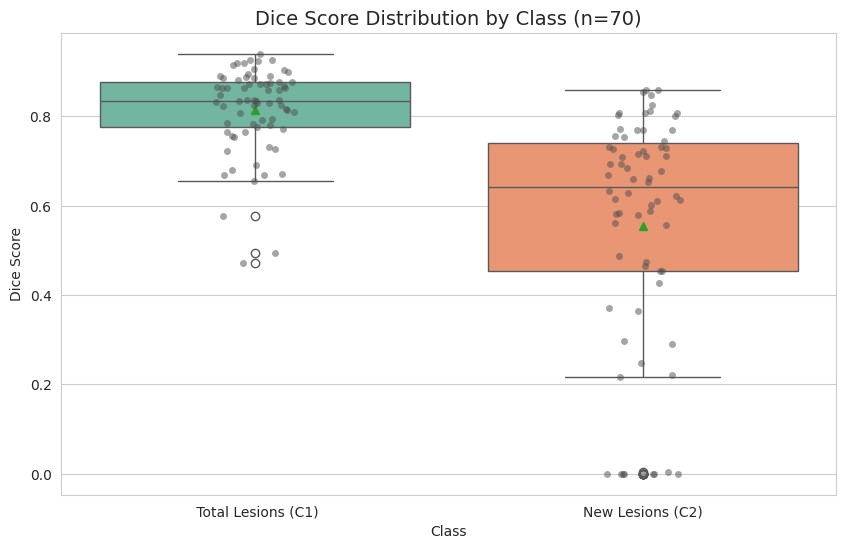

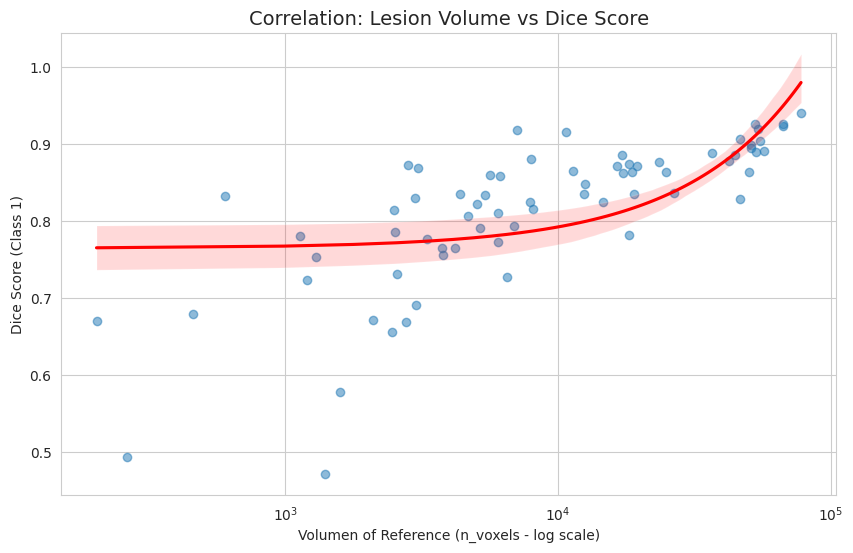

In [5]:
# Load data
with open('/content/nnUNet_results/Dataset001_MSLesions/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/summary.json') as f:
    data = json.load(f)

# Metrics per case
cases = []
for case in data['metric_per_case']:
    case_id = case['prediction_file'].split('/')[-1].replace('.nii.gz', '')
    cases.append({
        'Case': case_id,
        'Dice_Total': case['metrics']['1']['Dice'],
        'Dice_New': case['metrics']['2']['Dice'],
        'Volume_Total': case['metrics']['1']['n_ref']
    })

df = pd.DataFrame(cases)

# Class comparison boxplot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
df_melted = df.melt(value_vars=['Dice_Total', 'Dice_New'], var_name='Class', value_name='Dice Score')
ax = sns.boxplot(x='Class', y='Dice Score', data=df_melted, palette='Set2', showmeans=True)
sns.stripplot(x='Class', y='Dice Score', data=df_melted, color=".3", alpha=0.5)
plt.title('Dice Score Distribution by Class (n=70)', fontsize=14)
plt.xticks([0, 1], [' Total Lesions (C1)', 'New Lesions (C2)'])
plt.savefig('boxplot_dice_classes.png', dpi=300)
plt.show()

# Volume vs. precision correlation ("Small Object Problem")
plt.figure(figsize=(10, 6))
sns.regplot(x='Volume_Total', y='Dice_Total', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xscale('log')
plt.title('Correlation: Lesion Volume vs Dice Score', fontsize=14)
plt.xlabel('Volumen of Reference (n_voxels - log scale)')
plt.ylabel('Dice Score (Class 1)')
plt.savefig('correlation_vol_dice.png', dpi=300)
plt.show()

### MRI Comparison Generation

Automatically selected slice with highest predicted lesion load: 158


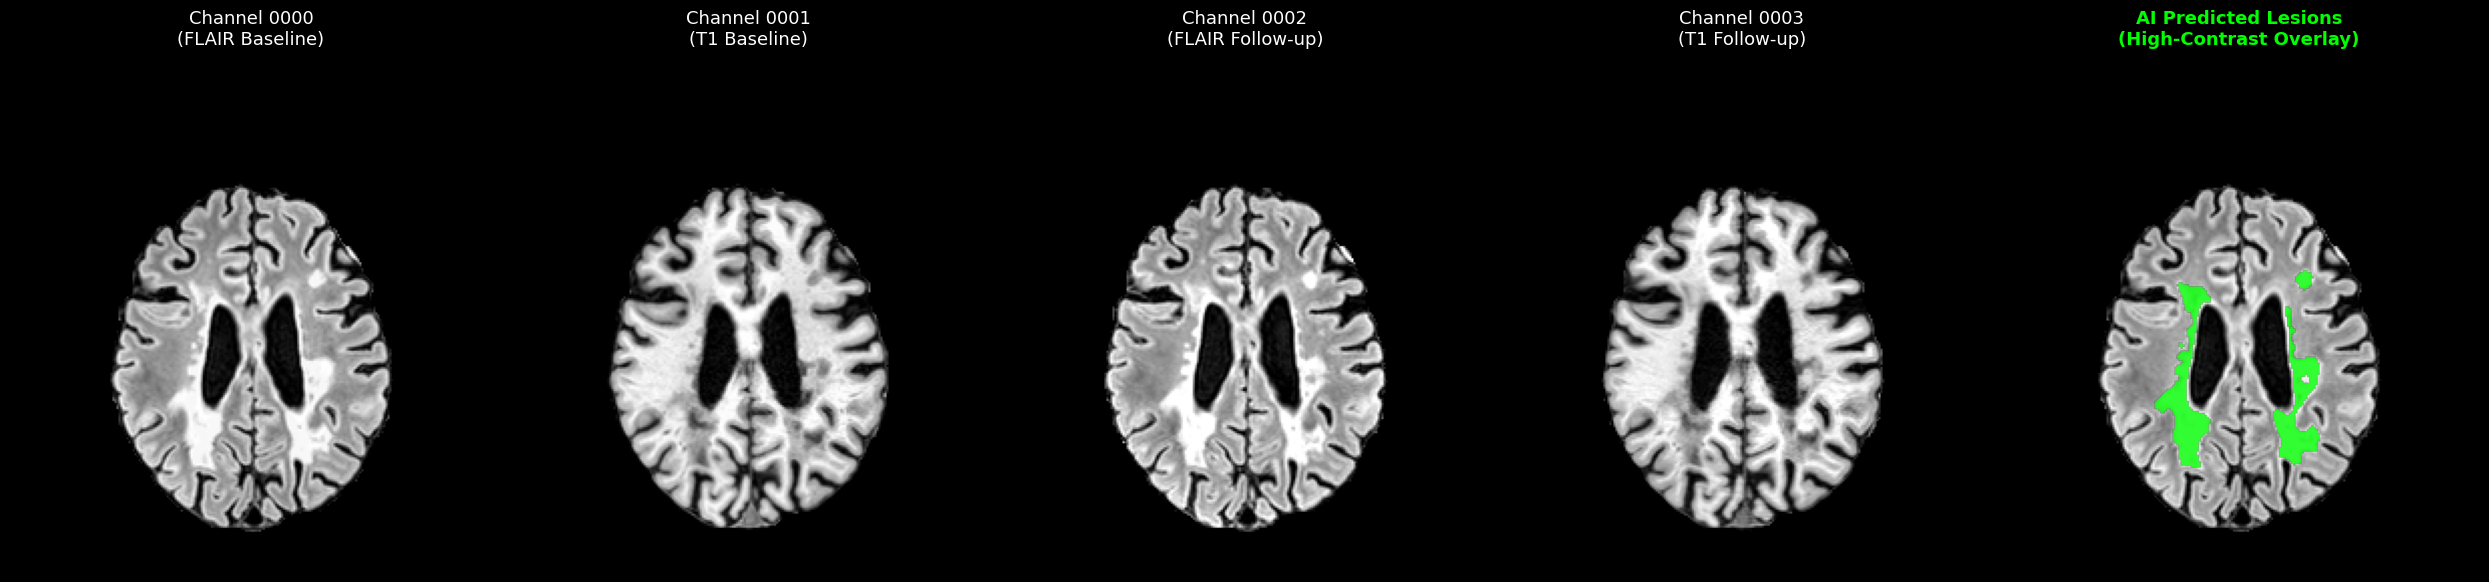

In [2]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

DATA_DIR = '/content/'
CASE_ID = 'FIS06201'  # To be changed for any other file or path

ch0_path = os.path.join(DATA_DIR, f'{CASE_ID}_0000.nii')
ch1_path = os.path.join(DATA_DIR, f'{CASE_ID}_0001.nii')
ch2_path = os.path.join(DATA_DIR, f'{CASE_ID}_0002.nii')
ch3_path = os.path.join(DATA_DIR, f'{CASE_ID}_0003.nii')
pred_path = os.path.join(DATA_DIR, f'{CASE_ID}.nii')

# Load data
img_0 = nib.load(ch0_path).get_fdata()
img_1 = nib.load(ch1_path).get_fdata()
img_2 = nib.load(ch2_path).get_fdata()
img_3 = nib.load(ch3_path).get_fdata()
img_pred = nib.load(pred_path).get_fdata()

# Best section of the lesion
best_slice = np.argmax(np.sum(img_pred > 0, axis=(0, 1)))
print(f"Automatically selected slice with highest predicted lesion load: {best_slice}")

# Function to apply contrast
def get_contrast_limits(slice_data, p_min=1.0, p_max=99.5):
    brain_voxels = slice_data[slice_data > 0]
    if len(brain_voxels) == 0:
        return None, None
    return np.percentile(brain_voxels, p_min), np.percentile(brain_voxels, p_max)

ai_color = 'lime'
cmap_ai = LinearSegmentedColormap.from_list('solid_ai', [ai_color, ai_color], N=2)

# Plot the high-contrast 5-column panel
fig, axes = plt.subplots(1, 5, figsize=(25, 6), facecolor='black') # Black background for maximum pop

images = [img_0, img_1, img_2, img_3]
titles = [
    'Channel 0000\n(FLAIR Baseline)',
    'Channel 0001\n(T1 Baseline)',
    'Channel 0002\n(FLAIR Follow-up)',
    'Channel 0003\n(T1 Follow-up)'
]

# Plot standard input channels with local contrast adaptation
for i in range(4):
    slice_to_show = np.rot90(images[i][:, :, best_slice])
    vmin, vmax = get_contrast_limits(slice_to_show)

    axes[i].imshow(slice_to_show, cmap='gray', vmin=vmin, vmax=vmax)
    axes[i].set_title(titles[i], fontsize=13, color='white', pad=10)

# Column 5: High-Contrast Overlay (AI Prediction on FLAIR Baseline)
flair_bg = np.rot90(img_0[:, :, best_slice])
vmin_f, vmax_f = get_contrast_limits(flair_bg)

# Base structural image
axes[4].imshow(flair_bg, cmap='gray', vmin=vmin_f, vmax=vmax_f)

# Processed mask overlay
pred_mask = np.rot90(img_pred[:, :, best_slice])
masked_pred = np.ma.masked_where(pred_mask == 0, pred_mask)

# Overlaying with solid color and perfect transparency alpha
axes[4].imshow(masked_pred, cmap=cmap_ai, alpha=0.8)
axes[4].set_title('AI Predicted Lesions\n(High-Contrast Overlay)', fontsize=13, color='lime', pad=10, weight='bold')

# Clean up layout axes
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'high_contrast_prediction_{CASE_ID}.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## Upload validation dataset

In [10]:
# Move the token to the hidden settings folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download de dataset from Kaggle, faster than locally
!pip install kaggle --upgrade > /dev/null
!kaggle datasets download -d manuelnavarrosicre/MSSEG-2 # Change "username" for yours

# Create destination folder and unzip
!mkdir -p /content/nnUNet_raw/MSSEG-2
!unzip -q MSSEG-2.zip -d /content/nnUNet_raw/MSSEG-2

!rm MSSEG-2.zip

print("Dataset ready")
!ls -l /content/nnUNet_raw/MSSEG-2

Dataset URL: https://www.kaggle.com/datasets/manuelnavarrosicre/MSSEG-2
License(s): CC0-1.0
100% 5.29G/5.29G [00:48<00:00, 116MB/s] 

Dataset ready
total 4
drwxr-xr-x 3 root root 4096 May 17 14:55 '_= LongitudinalMultipleSclerosisLesionSegmentationChallengeMiccai21'


In [12]:
# Configuration (Parameters)
# Source: Path where MSSEG-2 raw data was extracted
SOURCE_DIR = '/content/nnUNet_raw/MSSEG-2/training/'

# Destination: Folder where nnU-Net will look for images to predict
INFERENCE_DIR = '/content/msseg2_input/'

# Filenames used in MSSEG-2 dataset
FLAIR_T1_NAME = 'flair_time01_on_middle_space.nii'
FLAIR_T2_NAME = 'flair_time02_on_middle_space.nii'

# Create destination directory
os.makedirs(INFERENCE_DIR, exist_ok=True)

# List all patient directories
patient_ids = [f for f in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, f))]

print(f"Processing {len(patient_ids)} patients for external validation...")

for pid in patient_ids:
    patient_path = os.path.join(SOURCE_DIR, pid)

    # Source file paths
    src_flair_t1 = os.path.join(patient_path, FLAIR_T1_NAME)
    src_flair_t2 = os.path.join(patient_path, FLAIR_T2_NAME)

    if os.path.exists(src_flair_t1) and os.path.exists(src_flair_t2):
        # nnU-Net Channel Mapping:
        # 0000 -> FLAIR T1 (Baseline)
        # 0001 -> T1 T1    (Baseline - CLONED FROM FLAIR)
        # 0002 -> FLAIR T2 (Follow-up)
        # 0003 -> T1 T2    (Follow-up - CLONED FROM FLAIR)

        shutil.copy(src_flair_t1, os.path.join(INFERENCE_DIR, f"MSSEG_{pid}_0000.nii"))
        shutil.copy(src_flair_t1, os.path.join(INFERENCE_DIR, f"MSSEG_{pid}_0001.nii"))
        shutil.copy(src_flair_t2, os.path.join(INFERENCE_DIR, f"MSSEG_{pid}_0002.nii"))
        shutil.copy(src_flair_t2, os.path.join(INFERENCE_DIR, f"MSSEG_{pid}_0003.nii"))
    else:
        print(f"Warning: Missing files for patient {pid}. Skipping...")

print(f"\nData preparation complete.")
print(f"Total files generated in {INFERENCE_DIR}: {len(os.listdir(INFERENCE_DIR))}")

Processing 40 patients for external validation...

Data preparation complete.
Total files generated in /content/msseg2_input/: 160


### Run inference (external validation)


In [18]:
# -i: Input folder containing the prepared 4-channel images
# -o: Output folder where the predicted lesion masks will be saved
# -d: Dataset ID (1) corresponding to the training configuration
# -c: Model configuration (3d_fullres) for maximum spatial precision
# -f: Fold index (0) to load weights from the first cross-validation fold
# -chk: Specific checkpoint filename to load the best historical weights (by default: checkpoint_final.pth)
!nnUNetv2_predict -i /content/msseg2_input -o /content/msseg2_predictions -d 1 -c 3d_fullres -f 0 -chk checkpoint_best.pth


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 40 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 40 cases that I would like to predict

Predicting MSSEG_013:
perform_everything_on_device: True
100% 36/36 [00:37<00:00,  1.04s/it]
sending off prediction to background worker for resampling and export
done with MSSEG_013

Predicting MSSEG_015:
perform_everything_on_device: True
100% 36/36 [00:37<00:00,  1.04s/it]
sending off prediction to background worker for resampling and export
done with MSSEG_015

Predicting MSSEG_016:
perform_everything_on_device: True
100% 45

In [19]:
def dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-8)

# Paths configuration
path_gt_base = '/content/nnUNet_raw/MSSEG-2/training/'
path_pred = '/content/msseg2_predictions/'

res = []
predicted_files = [f for f in os.listdir(path_pred) if f.endswith('.nii')]

for f in predicted_files:
    # ID (i.e.: MSSEG_013.nii to 013)
    paciente_id = f.replace('MSSEG_', '').replace('.nii', '')

    # Load prediction
    pred_img = nib.load(os.path.join(path_pred, f)).get_fdata()
    pred_img = (pred_img > 0).astype(float)

    # Ground Truth
    gt_path = os.path.join(path_gt_base, paciente_id, 'ground_truth.nii')
    if os.path.exists(gt_path):
        gt_img = nib.load(gt_path).get_fdata()
        gt_img = (gt_img > 0).astype(float)

        # Dice score
        score = dice_coefficient(gt_img, pred_img)

        res.append({
            'MRI image': paciente_id,
            'Dice Score': round(score, 4)
        })

df = pd.DataFrame(res)
print("External validation results (MSSEG-2)")
print(df)

if not df.empty:
    print(f"\nDICE mean: {round(df['Dice Score'].mean(), 4)}")

External validation results (MSSEG-2)
   MRI image  Dice Score
0        083      0.0167
1        030      0.0027
2        077      0.0019
3        057      0.0917
4        027      0.0559
5        024      0.0122
6        070      0.0000
7        094      0.0002
8        032      0.0000
9        047      0.0000
10       048      0.0214
11       021      0.0442
12       089      0.0000
13       043      0.0078
14       096      0.0000
15       061      0.0398
16       039      0.4335
17       016      0.0250
18       037      0.0000
19       090      0.0000
20       020      0.0111
21       018      0.0011
22       052      0.0000
23       088      0.0000
24       099      0.0065
25       084      0.0000
26       049      0.0000
27       051      0.0000
28       100      0.0036
29       069      0.2349
30       029      0.0061
31       091      0.0199
32       026      0.0179
33       074      0.0592
34       019      0.0000
35       095      0.4198
36       035      0.0190
37       068

### MRI Comparison Generation

In [30]:
def plot_external_validation(flair_path, gt_path, pred_path, slice_idx=85):

    # Load files .nii
    flair = nib.load(flair_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()
    fig, ax = plt.subplots(1, 3, figsize=(20, 7))

    # FLAIR
    ax[0].imshow(np.rot90(flair[:, :, slice_idx]), cmap='gray')
    ax[0].set_title('FLAIR Original', fontsize=15)

    # Ground Truth
    ax[1].imshow(np.rot90(flair[:, :, slice_idx]), cmap='gray')
    ax[1].imshow(np.rot90(gt[:, :, slice_idx]), cmap='jet', alpha=0.5) # Blue/green
    ax[1].set_title('Ground Truth', fontsize=15)

    # Prediction
    ax[2].imshow(np.rot90(flair[:, :, slice_idx]), cmap='gray')
    ax[2].imshow(np.rot90(pred[:, :, slice_idx]), cmap='hot', alpha=0.5) # Red/yellow
    ax[2].set_title('Prediction', fontsize=15, color='red')

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

Patient 039 -> Automatically selected slice with highest lesion load: 174


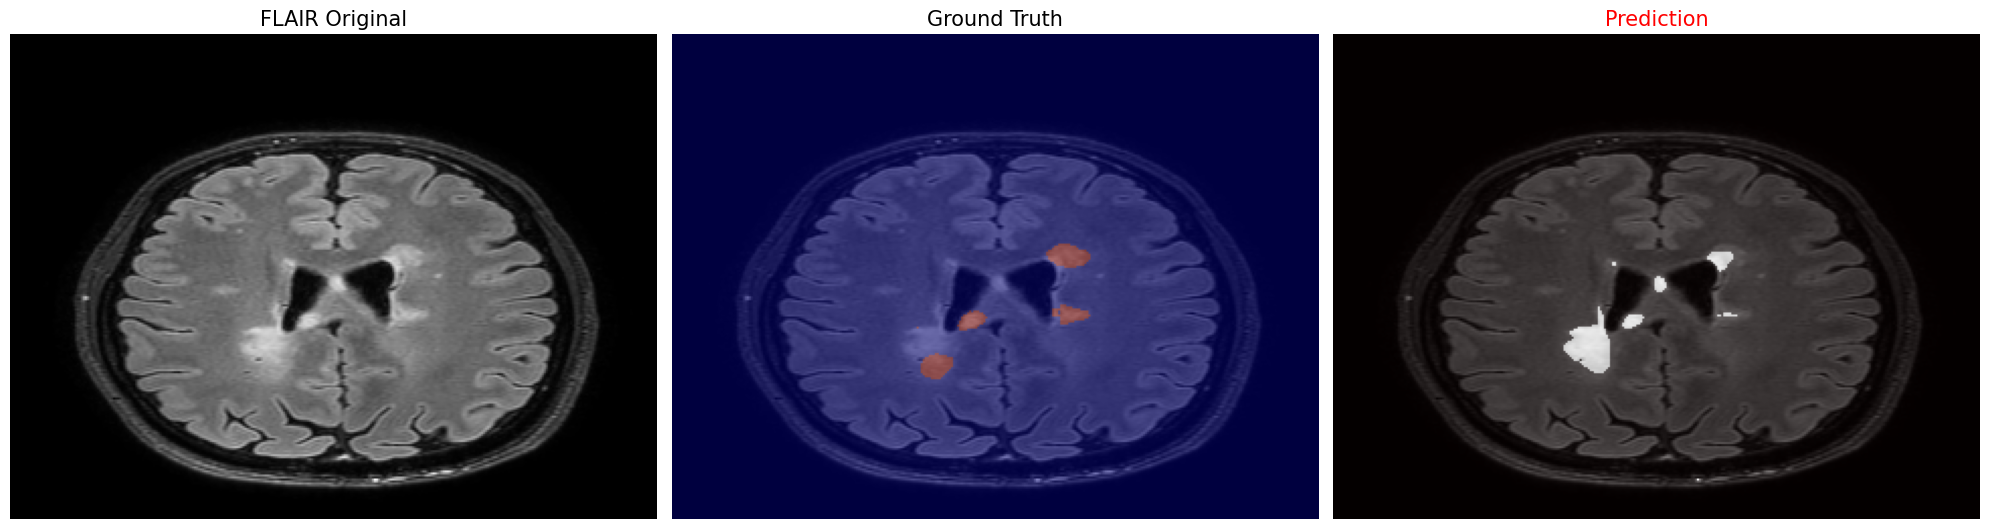

In [31]:
# Pre-defined base paths for external validation
path_gt_base = '/content/nnUNet_raw/MSSEG-2/training/'
path_pred = '/content/msseg2_predictions/'

# Select the patient ID
CASE_ID = '039'

# Path to the baseline FLAIR sequence of the selected patient
flair_path = os.path.join(path_gt_base, CASE_ID, 'flair_time02_on_middle_space.nii')

# Path to the Ground Truth
gt_path = os.path.join(path_gt_base, CASE_ID, 'ground_truth.nii')

# Path to the specific prediction file generated by nnU-Net
specific_pred_path = os.path.join(path_pred, f'MSSEG_{CASE_ID}.nii')

if os.path.exists(gt_path) and os.path.exists(specific_pred_path):
    # Load the Ground Truth data to automatically find the slice with most lesions
    gt_data = nib.load(gt_path).get_fdata()
    best_section = np.argmax(np.sum(gt_data > 0, axis=(0, 1)))

    print(f"Patient {CASE_ID} -> Automatically selected slice with highest lesion load: {best_section}")
    plot_external_validation(flair_path, gt_path, specific_pred_path, slice_idx=best_section)
else:
    print(f"ERROR: Could not find files for Patient {CASE_ID}.")
    print(f"Expected GT: {gt_path}")
    print(f"Expected Prediction: {specific_pred_path}")